save

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

from sklearn.datasets import make_classification, load_breast_cancer, load_wine
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.inspection import DecisionBoundaryDisplay

from sklearn.datasets import load_iris
from sklearn.linear_model import LinearRegression

from sklearn.datasets import fetch_openml
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

import warnings
import pandas as pd

warnings.filterwarnings("ignore")



seed = 1234
np.random.seed(seed)


df = pd.read_csv('data/diabetic_data.csv')
y=df['readmitted']
X=df.drop(columns=['encounter_id', 'patient_nbr','readmitted'])


In [2]:
X.head()

,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),?,1,1,7,3,?,?,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,...,No,No,No,No,No,No,No,No,No,Yes
3,Caucasian,Male,[30-40),?,1,1,7,2,?,?,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,Caucasian,Male,[40-50),?,1,1,7,1,?,?,...,No,No,Steady,No,No,No,No,No,Ch,Yes


In [3]:
y.head()

0     NO
1    >30
2     NO
3     NO
4     NO
Name: readmitted, dtype: str

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np

print("Starting Preprocessing...")

y_raw = df['readmitted'].values.ravel()
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)

X_raw = X.replace('?', np.nan)

numeric_features = X_raw.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_raw.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features)
    ])

print("Applying transofmrations...")
X_preprocessed = preprocessor.fit_transform(X_raw)

seed = 1234
np.random.seed(seed)

print("Splitting data...")
X_temp, X_te, y_temp, y_te = train_test_split(
    X_preprocessed, y_encoded, test_size=0.60, random_state=seed, stratify=y_encoded)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp)

print("Success, X_tr, y_tr, X_test, and y_test are now defined in memory.")

Starting Preprocessing...
Applying transofmrations...
Splitting data...
Success, X_tr, y_tr, X_test, and y_test are now defined in memory.


Linear Regression

Nearest Centroid

MLP 

Logistic Classifiers

Starting Linear Regression...
Final Test Accuray: 50.52%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.02      0.04      6814
           1       0.40      0.68      0.51     21327
           2       0.65      0.49      0.56     32919

    accuracy                           0.51     61060
   macro avg       0.46      0.40      0.37     61060
weighted avg       0.53      0.51      0.48     61060



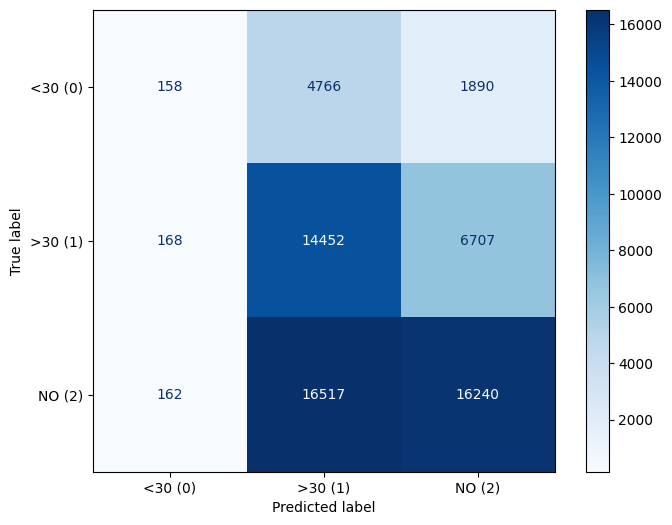

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

print("Starting Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_tr, y_tr)

lr_predictions_raw = lr_model.predict(X_te)
lr_predictions_rounded = np.clip(np.round(lr_predictions_raw), 0, 2).astype(int)

lr_acc = accuracy_score(y_te, lr_predictions_rounded)
print(f"Final Test Accuray: {lr_acc * 100:.2f}%\n")

print("Detailed Classification Report:")
print(classification_report(y_te, lr_predictions_rounded, zero_division=0))

cm = confusion_matrix(y_te, lr_predictions_rounded, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['<30 (0)', '>30 (1)', 'NO (2)'])
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.show()